In [29]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_iris

In [30]:
p = plt.rcParams  # 获取默认绘图参数
p["font.weight"] = "light"  # 设置字体粗细为 light
p["ytick.minor.visible"] = True  # 显示 y 轴的小刻度
p["xtick.minor.visible"] = True  # 显示 x 轴的小刻度
p["axes.grid"] = True  # 启用坐标轴网格
p["grid.color"] = "0.5"  # 设置网格颜色为灰色
p["grid.linewidth"] = 0.5  # 设置网格线宽度


In [31]:
iris_sns = sns.load_dataset('iris')
iris_sns

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


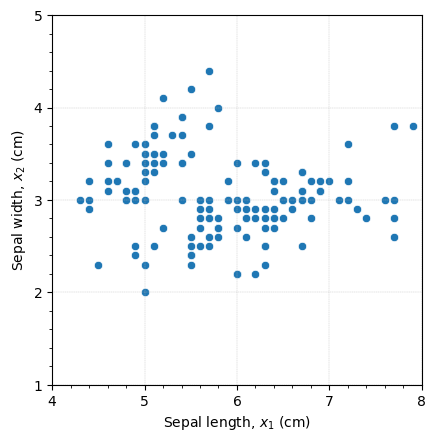

In [32]:
fig,ax = plt.subplots()

ax = sns.scatterplot(data = iris_sns,x = 'sepal_length',y = 'sepal_width')

ax.set_xlabel('Sepal length, $x_1$ (cm)')  # 设置 x 轴标签
ax.set_ylabel('Sepal width, $x_2$ (cm)')   # 设置 y 轴标签
ax.set_xticks(np.arange(4, 8 + 1, step=1))  # 设置 x 轴刻度
ax.set_yticks(np.arange(1, 5 + 1, step=1))  # 设置 y 轴刻度
ax.axis('scaled')  # 等比例缩放
ax.grid(linestyle='--', linewidth=0.25, color=[0.7,0.7,0.7])  # 添加网格
ax.set_xbound(lower=4, upper=8)  # 设置 x 轴边界
ax.set_ybound(lower=1, upper=5)  # 设置 y 轴边界


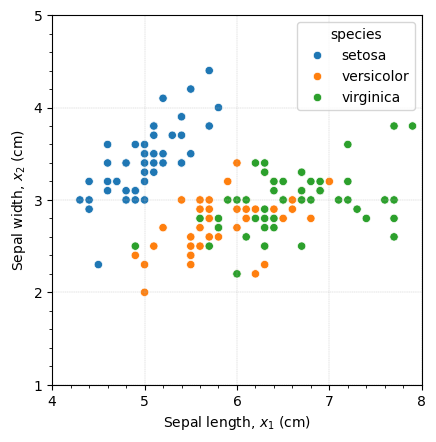

In [33]:
fig,ax = plt.subplots()

ax = sns.scatterplot(data = iris_sns,x = 'sepal_length',y = 'sepal_width',hue = 'species')

ax.set_xlabel('Sepal length, $x_1$ (cm)')  # 设置 x 轴标签
ax.set_ylabel('Sepal width, $x_2$ (cm)')   # 设置 y 轴标签
ax.set_xticks(np.arange(4, 8 + 1, step=1))  # 设置 x 轴刻度
ax.set_yticks(np.arange(1, 5 + 1, step=1))  # 设置 y 轴刻度
ax.axis('scaled')  # 等比例缩放
ax.grid(linestyle='--', linewidth=0.25, color=[0.7,0.7,0.7])  # 添加网格
ax.set_xbound(lower=4, upper=8)  # 设置 x 轴边界
ax.set_ybound(lower=1, upper=5)  # 设置 y 轴边界


In [34]:
x1 = iris_sns['sepal_length']
x2 = iris_sns['sepal_width']
x3 = iris_sns['petal_length']

#新版pd数组文件默认str数组类型将无法加入其他类型 object可以混用类型,这里先转换为object再复制
#astype(object) 放前面还是后面
labels = iris_sns['species'].copy().astype(object)

labels[labels == 'setosa'] = 1
labels[labels == 'versicolor'] = 2
labels[labels == 'virginica'] = 3
rainbow = plt.get_cmap('rainbow')
labels

0      1
1      1
2      1
3      1
4      1
      ..
145    3
146    3
147    3
148    3
149    3
Name: species, Length: 150, dtype: object

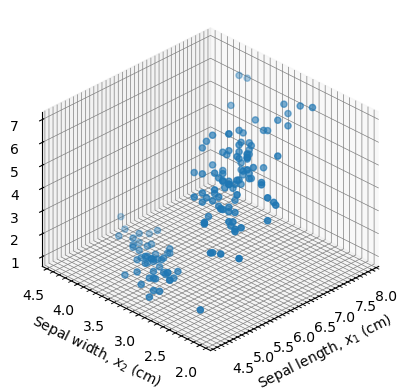

In [35]:
fig = plt.figure()
ax = plt.axes(projection = '3d')
ax.scatter(x1,x2,x3)

ax.set_xlabel('Sepal length, $x_1$ (cm)')
ax.set_ylabel('Sepal width, $x_2$ (cm)')
ax.set_zlabel('Petal length, $x_3$ (cm)')
ax.set_proj_type('ortho')  # 正交投影
ax.view_init(azim=-135, elev=30)

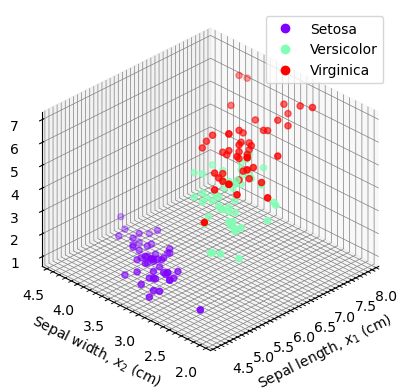

In [36]:
fig = plt.figure()
ax = plt.axes(projection = '3d')
scatter_h = ax.scatter(x1,x2,x3,c = labels,cmap = rainbow)

classes = ['Setosa','Versicolor','Virginica']
#legend会自动根据颜色生成图例元素,取[0]是取生成的小圆点,[1]是labels
#这里labels用自己的
plt.legend(handles = scatter_h.legend_elements()[0],labels = classes)

ax.set_xlabel('Sepal length, $x_1$ (cm)')
ax.set_ylabel('Sepal width, $x_2$ (cm)')
ax.set_zlabel('Petal length, $x_3$ (cm)')
ax.set_proj_type('ortho')
ax.view_init(azim=-135, elev=30)

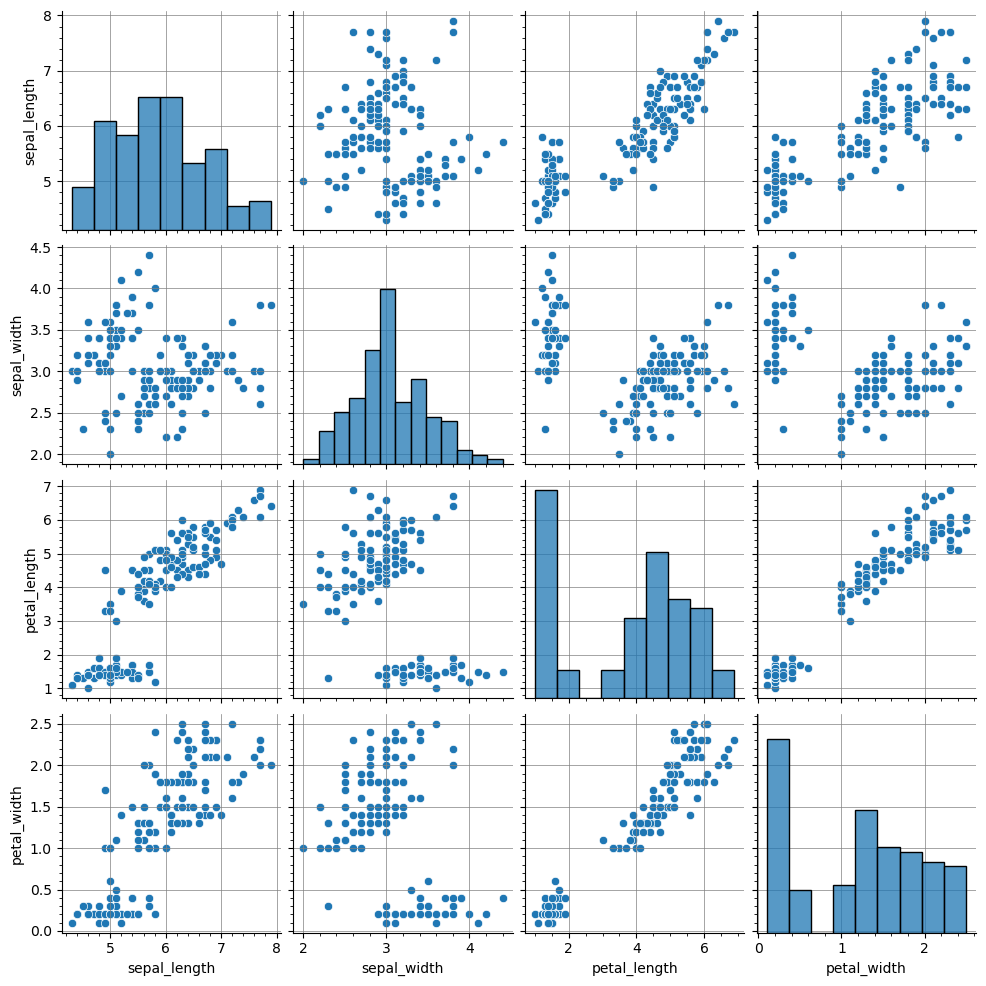

In [37]:
sns.pairplot(iris_sns)

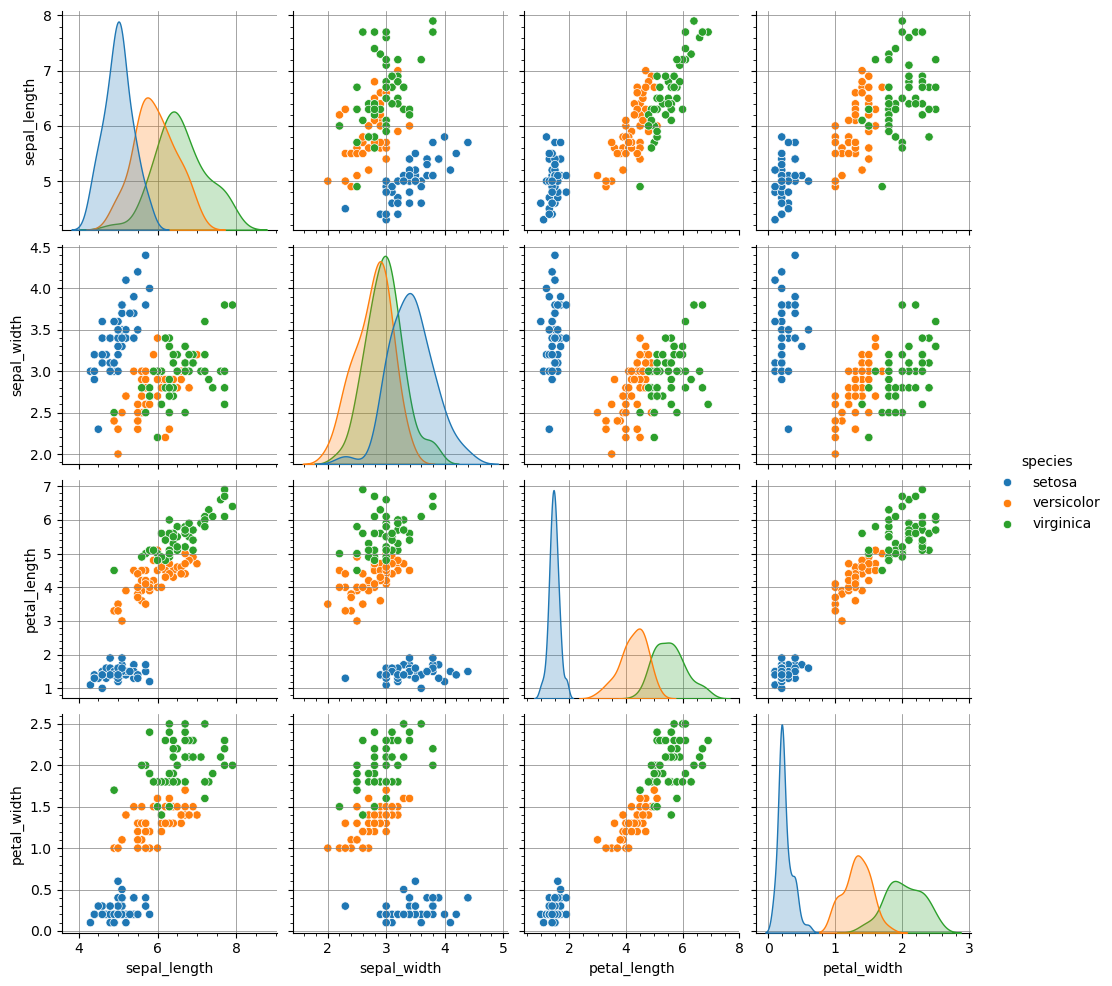

In [38]:
sns.pairplot(iris_sns,hue = 'species')

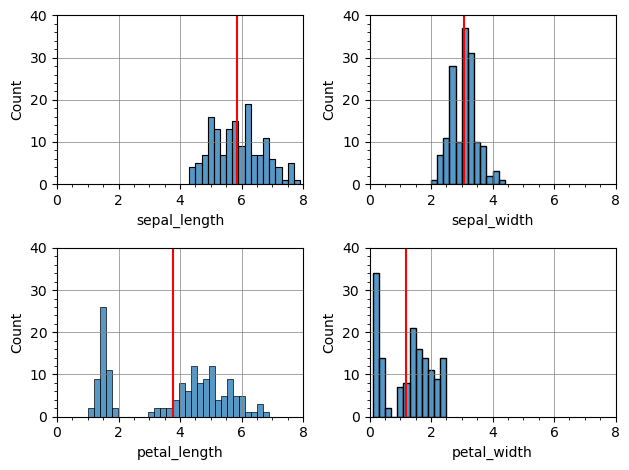

In [39]:
fig,axes = plt.subplots(2,2)

mu_1 = iris_sns['sepal_length'].mean()
sns.histplot(data = iris_sns,x = 'sepal_length',binwidth = 0.2,ax = axes[0][0])
axes[0][0].set_xlim([0,8])
axes[0][0].set_ylim([0,40])
axes[0][0].vlines(x = mu_1,ymin = 0,ymax = 40,color = 'r')

mu_2 = iris_sns['sepal_width'].mean()
sns.histplot(data = iris_sns,x = 'sepal_width',binwidth = 0.2,ax = axes[0][1])
axes[0][1].set_xlim([0,8])
axes[0][1].set_ylim([0,40])
axes[0][1].vlines(x = mu_2,ymin = 0,ymax = 40,color = 'r')

mu_3 = iris_sns['petal_length'].mean()
sns.histplot(data = iris_sns,x = 'petal_length',binwidth = 0.2,ax = axes[1][0])
axes[1][0].set_xlim([0,8])
axes[1][0].set_ylim([0,40])
axes[1][0].vlines(x = mu_3,ymin = 0,ymax = 40,color = 'r')

mu_4 = iris_sns['petal_width'].mean()
sns.histplot(data = iris_sns,x = 'petal_width',binwidth = 0.2,ax = axes[1][1])
axes[1][1].set_xlim([0,8])
axes[1][1].set_ylim([0,40])
axes[1][1].vlines(x = mu_4,ymin = 0,ymax = 40,color = 'r')

plt.tight_layout()

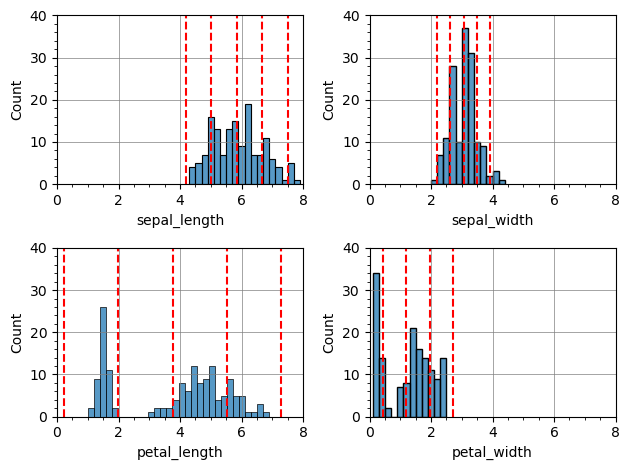

In [44]:
num = 0
fig,axes = plt.subplots(2,2)
for i in [0,1]:
    for j in [0,1]:
        sns.histplot(data = iris_sns,x = iris_sns.columns[num],
                     binwidth = 0.2,ax = axes[i][j])
        axes[i][j].set_xlim([0,8])
        axes[i][j].set_ylim([0,40])

        mu = iris_sns.iloc[:,num].mean()#计算均值
        std = iris_sns.iloc[:,num].std()#计算标准差

        axes[i][j].axvline(x = mu,color = 'r',linestyle = '--')
        axes[i][j].axvline(x = mu - std,color = 'r',linestyle = '--')
        axes[i][j].axvline(x = mu + std,color = 'r',linestyle = '--')
        axes[i][j].axvline(x = mu - 2*std,color = 'r',linestyle = '--')
        axes[i][j].axvline(x = mu + 2*std,color = 'r',linestyle = '--')

        num += 1

plt.tight_layout()

Text(0.5, 1.0, '$\\Sigma')

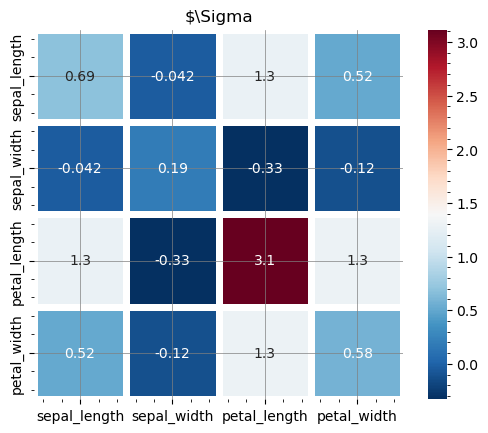

In [49]:
#loc用布尔数组是对第一维度的完整的选择, iloc只能用切片
SIGMA = iris_sns.iloc[:,:-1].cov()

fig,axs = plt.subplots()
h = sns.heatmap(SIGMA,cmap = 'RdBu_r',linewidth = 5,annot = True)
h.set_aspect('equal')
h.set_title(r'$\Sigma')

Text(0.5, 1.0, 'Y = 0 , virginica')

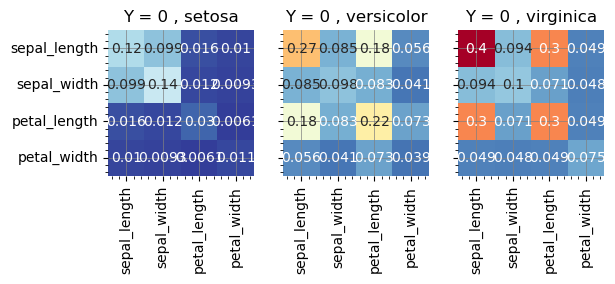

In [53]:
f,(ax1,ax2,ax3) = plt.subplots(1,3,sharey = True)

g1 = sns.heatmap(iris_sns.loc[iris_sns['species'] == 'setosa'].iloc[:,:-1].cov(),#
                 cmap = 'RdYlBu_r',annot = True,cbar = False,ax = ax1,square = True,
                 vmax = 0.4,vmin = 0)
ax1.set_title('Y = 0 , setosa')

g2 = sns.heatmap(iris_sns.loc[iris_sns['species'] == 'versicolor'].iloc[:,:-1].cov(),
                 cmap = 'RdYlBu_r',annot = True,cbar = False,ax = ax2,square = True,
                 vmax = 0.4,vmin = 0)
ax2.set_title('Y = 0 , versicolor')

g2 = sns.heatmap(iris_sns.loc[iris_sns['species'] == 'virginica'].iloc[:,:-1].cov(),
                 cmap = 'RdYlBu_r',annot = True,cbar = False,ax = ax3,square = True,
                 vmax = 0.4,vmin = 0)
ax3.set_title('Y = 0 , virginica')

Text(0.5, 1.0, '$Ρ$')

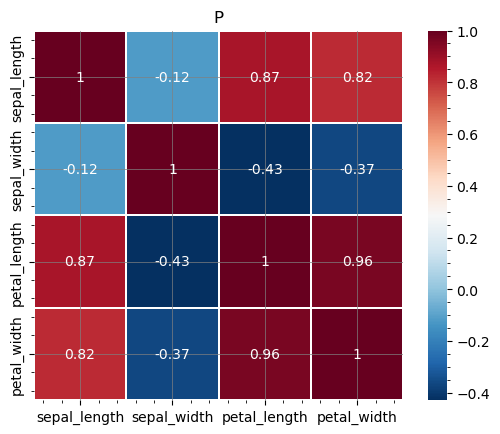

In [55]:
RHO = iris_sns.iloc[:,:-1].corr()

fig,ax = plt.subplots()
h = sns.heatmap(RHO,cmap = 'RdBu_r',linewidths = .05,annot = True)
h.set_aspect('equal')
h.set_title('$\u03A1$')

Text(0.5, 1.0, 'Y = 0 , virginica')

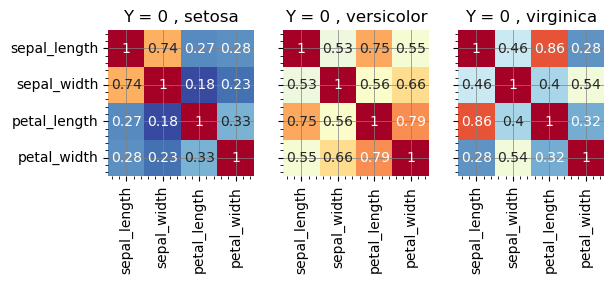

In [57]:
f,(ax1,ax2,ax3) = plt.subplots(1,3,sharey = True)

g1 = sns.heatmap(iris_sns.loc[iris_sns['species'] == 'setosa'].iloc[:,:-1].corr(),
                 cmap = 'RdYlBu_r',annot = True,cbar = False,ax = ax1,square = True,
                 vmax = 1,vmin = 0.15)
ax1.set_title('Y = 0 , setosa')

g2 = sns.heatmap(iris_sns.loc[iris_sns['species'] == 'versicolor'].iloc[:,:-1].corr(),
                 cmap = 'RdYlBu_r',annot = True,cbar = False,ax = ax2,square = True,
                 vmax = 1,vmin = 0.15)
ax2.set_title('Y = 0 , versicolor')

g2 = sns.heatmap(iris_sns.loc[iris_sns['species'] == 'virginica'].iloc[:,:-1].corr(),
                 cmap = 'RdYlBu_r',annot = True,cbar = False,ax = ax3,square = True,
                 vmax = 1,vmin = 0.15)
ax3.set_title('Y = 0 , virginica')